In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

In [4]:
hg16 = []
indexlistg16 = []

for i in range(len(bd)):
    if isinstance((bd.iloc[i]['lat_stereo_g16']), str) == True:
        deltalat = degtom(np.abs(literal_eval(bd.iloc[i]['lat_stereo_g16'])[0] - literal_eval(bd.iloc[i]['lat_stereo_g16'])[-1]))
        deltalong = degtom(np.abs(literal_eval(bd.iloc[i]['lon_stereo_g16'])[0] - literal_eval(bd.iloc[i]['lon_stereo_g16'])[-1]))
        deltaalt = (np.abs(literal_eval(bd.iloc[i]['alt_stereo_g16'])[0] - literal_eval(bd.iloc[i]['alt_stereo_g16'])[-1]))*1000
        hg16.append(np.sqrt(deltalat**2+deltalong**2+deltaalt**2))
        indexlistg16.append(i)

In [5]:
hg17 = []
indexlistg17 = []

for i in range(len(bd)):
    if isinstance((bd.iloc[i]['lat_stereo_g17']), str) == True:
        deltalat = degtom(np.abs(literal_eval(bd.iloc[i]['lat_stereo_g17'])[0] - literal_eval(bd.iloc[i]['lat_stereo_g17'])[-1]))
        deltalong = degtom(np.abs(literal_eval(bd.iloc[i]['lon_stereo_g17'])[0] - literal_eval(bd.iloc[i]['lon_stereo_g17'])[-1]))
        deltaalt = (np.abs(literal_eval(bd.iloc[i]['alt_stereo_g17'])[0] - literal_eval(bd.iloc[i]['alt_stereo_g17'])[-1]))*1000
        hg17.append(np.sqrt(deltalat**2+deltalong**2+deltaalt**2))
        indexlistg17.append(i)

In [6]:
hg18 = []
indexlistg18 = []

for i in range(len(bd)):
    if isinstance((bd.iloc[i]['lat_stereo_g18']), str) == True:
        deltalat = degtom(np.abs(literal_eval(bd.iloc[i]['lat_stereo_g18'])[0] - literal_eval(bd.iloc[i]['lat_stereo_g18'])[-1]))
        deltalong = degtom(np.abs(literal_eval(bd.iloc[i]['lon_stereo_g18'])[0] - literal_eval(bd.iloc[i]['lon_stereo_g18'])[-1]))
        deltaalt = (np.abs(literal_eval(bd.iloc[i]['alt_stereo_g18'])[0] - literal_eval(bd.iloc[i]['alt_stereo_g18'])[-1]))*1000
        hg18.append(np.sqrt(deltalat**2+deltalong**2+deltaalt**2))
        indexlistg17.append(i)

In [7]:
np.max(hg16)

60652.18378157143

In [8]:
np.max(hg17)

61429.879978471545

In [9]:
np.max(hg18)

15391.630042838397

In [10]:
for i in range(len(hg17)):
    if hg17[i] == np.max(hg17):
        print(i)

46


In [11]:
indexlistg17[46]

186

In [12]:
bd.iloc[186]

Unnamed: 0                                     186
datetime          2020-11-18,09:06:01.947815+00:00
longitude                              -119.267044
latitude                                 42.964489
source                                glm-pipeline
                                ...               
moon_fullness                             0.214892
solarhour                                  1.39548
sun_alt_obs                              -60.55434
sun_alt_app                              -60.55434
date_retrieved                7/22/2025,2:48:16,AM
Name: 186, Length: 90, dtype: object

In [13]:
b16= bd.iloc[186]

In [14]:
lat= literal_eval(b16['lat_stereo_g17'])
long= literal_eval(b16['lon_stereo_g17'])
alt= literal_eval(b16['alt_stereo_g17'])
energy = literal_eval(b16['energyJoules_stereo_g17'])

In [15]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))
    
bestfit= [] #bestfit must be defined outside of the function so that it can be used as a variable

def linearregression(x, y): #create a linear best fit for some data x and y
    sumxy=0 #need to be computed in a loop (cant use np.sum) so they're defined as 0 here and then summed later
    sumxsquare= 0
    sumx = np.sum(x)
    sumy = np.sum(y)
    n = len(x)
    for i in range(len(x)): #compute the correct sum(x*y)
        sumxy= sumxy+(x[i]*y[i])
    for i in range (len(x)): #compute the correct sun(x**2). this is DIFFERENT than sum(x)**2
        sumxsquare = sumxsquare + x[i]**2

    atop = (sumy*sumxsquare) - (sumx*sumxy) #defining atop and abottom separately to avoid accidentally coding in silly errors
    abottom = (n*sumxsquare) - sumx**2
    a = atop/abottom #a is our intercept in our linear equation. equavalent to b in y=mx+b but a+bx is the statistical notation I found
    btop = (n*sumxy) - (sumx*sumy) #similarly splitting b to avoid errors
    bbottom = (n*sumxsquare) - sumx**2
    b = btop/bbottom #b is the slope of our linear equation
    plt.scatter(x,y) #plot our original data as a scatter plot
    plt.plot (x, (a+b*x)) #plot our best fit line on the same graph

    for i in range (len(x)): #lastly...
        bestfit.append (a+b*x[i]) #... append each point on our best fit line to a list we can use for later calculations!

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [16]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

197


In [17]:
totalmass= 0
totalh= 0 
for i in range (197): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [18]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.00032831366925691887 0.00015321304565322878 0.0015321304565322881


In [19]:
totalh

58506.02510348224

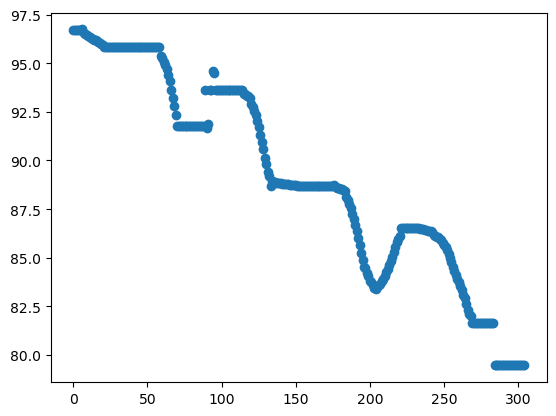

In [20]:
plt.scatter(range(len(alt)), alt)

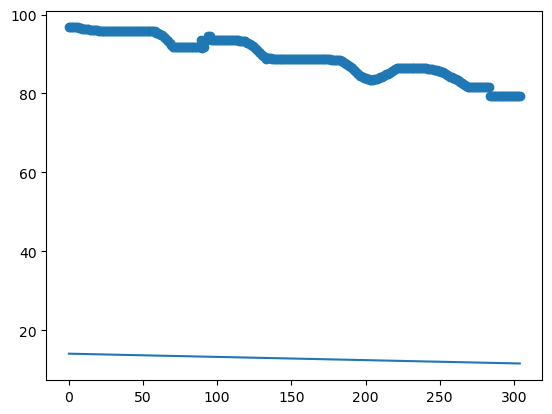

In [21]:
linearregression(range(len(alt)), alt)

In [22]:
bestfit

[14.060856297274826,
 14.052688585433623,
 14.04452087359242,
 14.036353161751217,
 14.028185449910014,
 14.020017738068812,
 14.01185002622761,
 14.003682314386406,
 13.995514602545203,
 13.987346890704,
 13.979179178862797,
 13.971011467021594,
 13.96284375518039,
 13.954676043339187,
 13.946508331497986,
 13.938340619656783,
 13.93017290781558,
 13.922005195974377,
 13.913837484133174,
 13.90566977229197,
 13.897502060450767,
 13.889334348609564,
 13.881166636768363,
 13.87299892492716,
 13.864831213085957,
 13.856663501244753,
 13.84849578940355,
 13.840328077562347,
 13.832160365721144,
 13.823992653879941,
 13.815824942038738,
 13.807657230197535,
 13.799489518356333,
 13.79132180651513,
 13.783154094673927,
 13.774986382832724,
 13.76681867099152,
 13.758650959150318,
 13.750483247309115,
 13.742315535467911,
 13.73414782362671,
 13.725980111785507,
 13.717812399944304,
 13.7096446881031,
 13.701476976261898,
 13.693309264420694,
 13.685141552579491,
 13.676973840738288,
 13.668

In [23]:
alt

[96.72831606,
 96.72758205,
 96.72709981,
 96.72790052,
 96.72872021,
 96.73003598,
 96.73185863,
 96.53617568,
 96.50284971,
 96.45436488,
 96.41192532,
 96.36422878,
 96.2969242,
 96.26327384,
 96.19049691,
 96.17231673,
 96.1174396,
 96.06701034,
 96.05701051,
 95.99029697,
 95.95089269,
 95.832386,
 95.83365446,
 95.83413785,
 95.8351522,
 95.83539323,
 95.83459763,
 95.83382305,
 95.83305607,
 95.83256754,
 95.83230518,
 95.83358966,
 95.83539227,
 95.83640488,
 95.83769426,
 95.83820616,
 95.83666952,
 95.83513121,
 95.83333745,
 95.83206641,
 95.83130458,
 95.83156785,
 95.83207211,
 95.83257371,
 95.83332784,
 95.83511264,
 95.83689478,
 95.83770092,
 95.83825914,
 95.83830356,
 95.83528773,
 95.83227021,
 95.8309224,
 95.82929613,
 95.82871465,
 95.83016332,
 95.83161199,
 95.83236109,
 95.83311511,
 95.37599916,
 95.25204231,
 95.07993401,
 94.92996649,
 94.7039486,
 94.3699618,
 94.08200155,
 93.62684666,
 93.21454652,
 92.81373355,
 92.35027908,
 91.7721059,
 91.77212525,
 

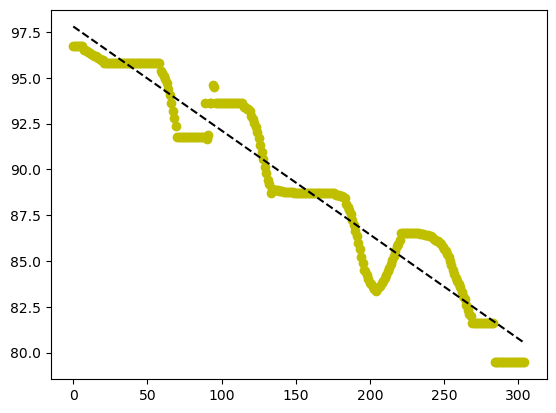

In [28]:
coef = np.polyfit(range(len(alt)), alt, 1)
poly1d_fn = np.poly1d(coef) 
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(range(len(alt)), alt, 'yo', range(len(alt)), poly1d_fn(range(len(alt))), '--k') #'--k'=black dashed line, 'yo' = yellow circle marker

In [37]:
poly1d_fn(range(len(alt)))

305

In [38]:
len(alt)

305